# D-07 — A História da Computação Quântica

- **Tipo:** Digressão
- **Referenciado por:** [D-00](D-00.ipynb)

<div style="border-left: 2px solid #6b7280; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(107, 114, 128, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #9ca3af;">etimologia</span><br>
  <span style="font-size: 0.88em; line-height: 1.65;"><b>Algoritmo</b> vem do nome do matemático persa Al-Khwārizmī (século IX), cujo nome latinizado — <i>Algoritmi</i> — deu origem ao termo. A ideia central é a de um procedimento finito e bem definido para resolver um problema. Carrega a ideia de que o processo, não só o resultado, importa.<br><b>Oráculo</b> vem do latim <i>oraculum</i>, de <i>orare</i> ("falar", "rezar"). Era o lugar onde se consultava uma divindade para obter respostas a perguntas difíceis. Em computação quântica, o oráculo é uma caixa-preta que responde perguntas — você não sabe como, apenas o que ela responde.</span>
</div>

## Afirmação introdutória

A computação quântica não surgiu de uma vez. Ela foi construída em camadas: primeiro a proposta de simular sistemas quânticos (Feynman, 1981), depois a formalização de um modelo de computação universal (Deutsch, 1985), depois os algoritmos que mostraram vantagem real (Shor, Grover, 1994–96). Cada camada dependia da anterior.

Este notebook reconstrói essa trajetória — não como lista de datas, mas como sequência de perguntas que se tornaram mais precisas ao longo do tempo.

## 1. A pergunta de Feynman (1981)

Em 1981, Richard Feynman propõe uma ideia simples e provocadora: **usar um sistema quântico para simular outro sistema quântico**.

O problema era concreto: simular como moléculas evoluem no tempo exige descrever estados quânticos — e o número de parâmetros cresce exponencialmente com o número de partículas. Para 50 elétrons, um computador clássico precisaria de mais bits de memória do que átomos no universo observável.

A proposta de Feynman era: prepare um sistema quântico controlável, faça-o evoluir segundo a dinâmica do sistema de interesse, meça no final. O sistema físico faz o trabalho — não a CPU.

Aqui, o foco ainda era `simulação quântica`, não computação quântica de propósito geral.

## 2. O modelo universal (Deutsch, 1985)

Em 1985, David Deutsch faz a pergunta mais geral: existe um modelo de computação quântica que seja **universal** — que possa simular eficientemente qualquer sistema quântico?

Ele define a `máquina de Turing quântica` e mostra que sim. Mais do que isso: ele propõe o primeiro problema onde um computador quântico tem vantagem sobre um clássico — o `algoritmo de Deutsch`, que distingue funções constantes de balanceadas com uma única consulta.

O problema é artificial, mas a separação é nítida. **Aqui nasce a computação quântica como modelo de computação**, não apenas simulação.

No mesmo ano, Asher Peres publica o primeiro `código de correção de erros` de bit quântico (código de 3 qubits).

## 3. Os algoritmos que mudaram tudo (1992–1996)

**1992 — Deutsch-Jozsa.** Deutsch e Jozsa refinam o problema original: com uma única consulta ao `oráculo`, o algoritmo quântico distingue funções que exigem exponencialmente mais consultas no caso clássico. É o primeiro exemplo célebre de vantagem quântica demonstrável. Bernstein e Vazirani dão rigor matemático ao modelo.

**1994 — Simon.** Dan Simon resolve o problema de `periodicidade num hipercubo` com separação exponencial entre clássico e quântico. Usa a `transformada de Fourier quântica`. O paper é rejeitado na conferência STOC — Peter Shor está no comitê que o rejeitou.

**1994 — Shor.** Peter Shor adapta a ideia de Simon. Percebe que `fatoração` e `logaritmo discreto` também são problemas de periodicidade — só que num grupo cíclico, não num hipercubo. **O resultado quebra RSA em tempo polinomial** num computador quântico. A `criptografia de chave pública`, como era praticada, ficou teoricamente vulnerável.

<a href="../matematica/M-04.ipynb" style="font-size: 0.82em; color: #6b7280; text-decoration: none; border-bottom: 1px dashed #6b7280; white-space: nowrap;">↳ A Transformada de Fourier e a QFT</a>

**1995 — Correção de erros.** A objeção de Landauer: o `teorema de não-clonagem` parece impedir qualquer correção de erros quânticos. Shor responde com o código de 9 qubits. Calderbank, Shor e Steane generalizam para a família de `códigos CSS`.

**1996 — Grover.** Lov Grover publica o `algoritmo de busca`: speedup quadrático para busca não-estruturada. Menos dramático que Shor, mas aplicável a uma classe muito mais ampla de problemas.

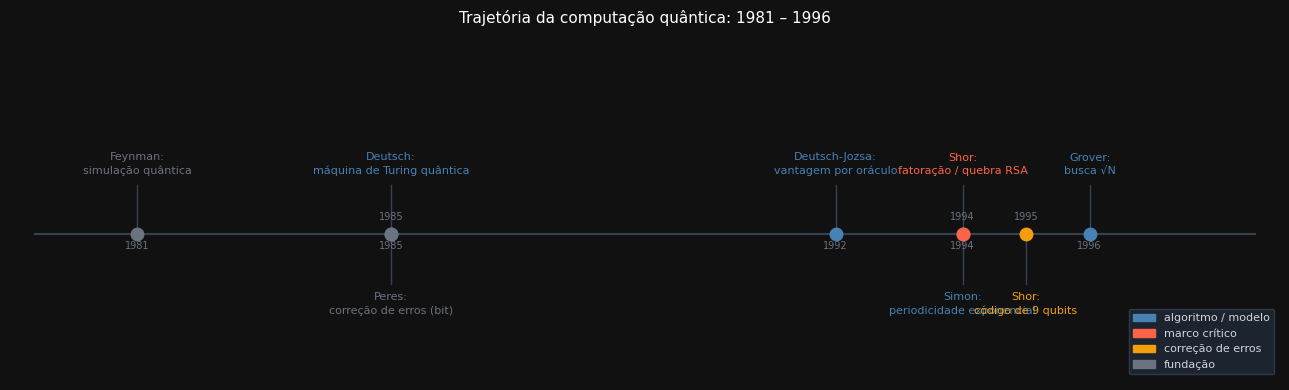

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Linha do tempo visual ────────────────────────────────────────────────────
eventos = [
    (1981, 'Feynman:\nsimulação quântica',      '#6b7280'),
    (1985, 'Deutsch:\nmáquina de Turing quântica', 'steelblue'),
    (1985, 'Peres:\ncorreção de erros (bit)',    '#6b7280'),
    (1992, 'Deutsch-Jozsa:\nvantagem por oráculo', 'steelblue'),
    (1994, 'Simon:\nperiodicidade exponencial',  'steelblue'),
    (1994, 'Shor:\nfatoração / quebra RSA',      'tomato'),
    (1995, 'Shor:\ncódigo de 9 qubits',          '#f59e0b'),
    (1996, 'Grover:\nbusca √N',                  'steelblue'),
]

fig, ax = plt.subplots(figsize=(13, 4), facecolor='#111')
fig.patch.set_facecolor('#111')
ax.set_facecolor('#111')
ax.set_xlim(1979, 1999)
ax.set_ylim(-1.5, 2)
ax.axis('off')

# Linha do tempo
ax.axhline(0, color='#374151', lw=1.5, xmin=0.02, xmax=0.98)

offsets = [0.6, 0.6, -0.6, 0.6, -0.6, 0.6, -0.6, 0.6]
for (ano, label, color), offset in zip(eventos, offsets):
    ax.plot(ano, 0, 'o', color=color, ms=9, zorder=3)
    ax.plot([ano, ano], [0, offset * 0.85], color='#374151', lw=1)
    ax.text(ano, offset, label, ha='center',
            va='bottom' if offset > 0 else 'top',
            color=color, fontsize=8, linespacing=1.4)
    ax.text(ano, -0.15 if offset > 0 else 0.15, str(ano),
            ha='center', color='#6b7280', fontsize=7)

legend_items = [
    mpatches.Patch(color='steelblue', label='algoritmo / modelo'),
    mpatches.Patch(color='tomato',    label='marco crítico'),
    mpatches.Patch(color='#f59e0b',   label='correção de erros'),
    mpatches.Patch(color='#6b7280',   label='fundação'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8,
          labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')

ax.set_title('Trajetória da computação quântica: 1981 – 1996',
             color='white', fontsize=11, pad=12)
plt.tight_layout()
plt.show()

## 4. Por que essa sequência importa

A trajetória não é acidental. Cada passo dependeu do anterior:

- Feynman mostrou que havia um problema que computadores clássicos não conseguem resolver eficientemente.
- Deutsch mostrou que existe um modelo de computação que pode resolver esses problemas.
- Simon mostrou que a `transformada de Fourier quântica` é o mecanismo central para problemas de periodicidade.
- Shor mostrou que a fatoração é um problema de periodicidade — e que isso tem consequências criptográficas reais.
- A correção de erros mostrou que o modelo é, em princípio, tolerante a ruído.

Sem Feynman, não há motivação. Sem Deutsch, não há modelo. Sem Simon, não há mecanismo. Sem Shor, não há urgência. Sem correção de erros, não há viabilidade.

## O que este notebook respondeu

A computação quântica foi construída em cinco camadas entre 1981 e 1996: simulação → modelo universal → vantagem por oráculo → algoritmo com impacto real → viabilidade por correção de erros. Cada camada responde a uma limitação da anterior.

## O que este notebook não respondeu

- Como os algoritmos funcionam em detalhe — <a href="../nucleo/N-04.ipynb" style="font-size: 0.82em; color: #6b7280; text-decoration: none; border-bottom: 1px dashed #6b7280; white-space: nowrap;">↳ N-04 (QPE)</a>, <a href="../nucleo/N-06.ipynb" style="font-size: 0.82em; color: #6b7280; text-decoration: none; border-bottom: 1px dashed #6b7280; white-space: nowrap;">↳ N-06 (Shor)</a>
- Como os qubits físicos foram sendo construídos ao longo desse período — <a href="D-08.ipynb" style="font-size: 0.82em; color: #6b7280; text-decoration: none; border-bottom: 1px dashed #6b7280; white-space: nowrap;">↳ D-08 — Arquiteturas Físicas</a>
- O estado atual do campo: limites de coerência, benchmarks, hardware real